In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 180)


In [2]:
BASE = "hf://datasets/hao-li/AIDev"

# AI-generated PRs
pr_df = pd.read_parquet(f"{BASE}/pull_request.parquet")

# Reviews
pr_reviews_df = pd.read_parquet(f"{BASE}/pr_reviews.parquet")
pr_review_comments_df = pd.read_parquet(f"{BASE}/pr_review_comments_v2.parquet")

# Commits & diffs
pr_commits_df = pd.read_parquet(f"{BASE}/pr_commits.parquet")
from huggingface_hub import hf_hub_download
import time

# Télécharger avec retries puis lire localement (évite les erreurs ChunkedEncoding)
for attempt in range(3):
    try:
        local_path = hf_hub_download(
            repo_id="hao-li/AIDev",
            filename="pr_commit_details.parquet",
            repo_type="dataset",
            cache_dir="./hf_cache"
        )
        pr_commit_details_df = pd.read_parquet(local_path)
        print("Loaded pr_commit_details.parquet from", local_path)
        break
    except Exception as e:
        print(f"Attempt {attempt+1} failed: {e}")
        time.sleep(5)
else:
    raise RuntimeError("Impossible de télécharger pr_commit_details.parquet après plusieurs tentatives")

print("Dataset loaded.")


c:\Users\mathi\anaconda3\Lib\site-packages\huggingface_hub\file_download.py:133: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\repos\fork\AI_Teammates_in_SE3\analysis\hf_cache. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to see activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


Loaded pr_commit_details.parquet from ./hf_cache\datasets--hao-li--AIDev\snapshots\eee0408a277826d88fc0ca5fa07d2fc325c96af1\pr_commit_details.parquet
Dataset loaded.


In [3]:
ai_pr = pr_df.rename(columns={"id": "pr_id"}).copy()

# Vérifier les agents disponibles
print("Agents IA disponibles :", ai_pr["agent"].value_counts())


Agents IA disponibles : agent
OpenAI_Codex    21799
Copilot          4970
Devin            4827
Cursor           1541
Claude_Code       459
Name: count, dtype: int64


In [4]:
# Build mapping review → PR
review_to_pr = pr_reviews_df[["id", "pr_id"]].rename(
    columns={"id": "pull_request_review_id", "pr_id": "pr_id"}
)

# Attach PR id to review comments
review_comments_with_pr = pr_review_comments_df.merge(
    review_to_pr, on="pull_request_review_id", how="left"
)


In [5]:
ADD_COL = "additions"
DEL_COL = "deletions"
FILE_COL = "filename"

patch_metrics_df = (
    pr_commit_details_df
    .groupby("pr_id")
    .agg(
        total_additions=(ADD_COL, "sum"),
        total_deletions=(DEL_COL, "sum"),
        files_touched=(FILE_COL, "nunique")
    )
    .reset_index()
)

patch_metrics_df["churn"] = patch_metrics_df["total_additions"] + patch_metrics_df["total_deletions"]

# Corrélation add/del (structure du patch)
def corr_add_del(g):
    if len(g) < 2:
        return np.nan
    if g[ADD_COL].std() == 0 or g[DEL_COL].std() == 0:
        return np.nan
    return g[ADD_COL].corr(g[DEL_COL])

corr_series = (
    pr_commit_details_df
    .groupby("pr_id")
    .apply(corr_add_del)
    .rename("add_del_corr")
)

patch_metrics_df = patch_metrics_df.merge(corr_series, on="pr_id", how="left")

patch_metrics_df["new_code_fraction"] = (
    patch_metrics_df["total_additions"] /
    patch_metrics_df["churn"].replace({0: np.nan})
)


c:\Users\mathi\anaconda3\Lib\site-packages\numpy\lib\function_base.py:2846: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
c:\Users\mathi\anaconda3\Lib\site-packages\numpy\lib\function_base.py:2705: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)


In [6]:
# Nombre de review comments
review_comments_df = (
    review_comments_with_pr
    .groupby("pr_id")
    .size()
    .rename("n_review_comments")
    .reset_index()
)

# CHANGES REQUESTED
review_state = pr_reviews_df.copy()
review_state["changes_requested"] = (
    review_state["state"].astype(str).str.contains("CHANGES_REQUESTED", case=False)
)

changes_requested_df = (
    review_state.groupby("pr_id")["changes_requested"].max().reset_index()
)


In [7]:
commit_count_df = (
    pr_commits_df
    .groupby("pr_id")
    .size()
    .rename("n_commits")
    .reset_index()
)

revision_cycles_df = changes_requested_df.merge(commit_count_df, on="pr_id", how="left")

revision_cycles_df["revision_cycle_detected"] = (
    (revision_cycles_df["changes_requested"] == True) &
    (revision_cycles_df["n_commits"] > 1)
)


In [8]:
metrics_df = (
    ai_pr[["pr_id", "agent"]]
    .merge(patch_metrics_df, on="pr_id", how="left")
    .merge(review_comments_df, on="pr_id", how="left")
    .merge(revision_cycles_df, on="pr_id", how="left")
)

metrics_df.head()


,pr_id,agent,total_additions,total_deletions,files_touched,churn,add_del_corr,new_code_fraction,n_review_comments,changes_requested,n_commits,revision_cycle_detected
0,3264933329,Claude_Code,394.0,2.0,3.0,396.0,-0.999996,0.994949,NaN,NaN,NaN,NaN
1,3265118634,Claude_Code,38.0,38.0,11.0,76.0,1.000000,0.500000,NaN,NaN,NaN,NaN
2,3265640341,Claude_Code,298.0,109.0,5.0,407.0,-0.302710,0.732187,2.0,False,6.0,False
3,3265709660,Claude_Code,288.0,12.0,15.0,300.0,-0.002694,0.960000,2.0,False,3.0,False
4,3265782173,Claude_Code,53.0,168.0,21.0,221.0,-0.112212,0.239819,NaN,NaN,NaN,NaN


In [9]:
cols = [
    "total_additions", "total_deletions", "churn",
    "files_touched", "add_del_corr", "new_code_fraction",
    "n_review_comments", "changes_requested",
    "n_commits", "revision_cycle_detected"
]

summary_by_agent = (
    metrics_df
    .groupby("agent")[cols]
    .agg(["count", "mean", "median", "std"])
)

summary_by_agent


total_additions                                   total_deletions                                    churn                                   files_touched  \
                       count         mean median           std           count         mean median           std  count         mean median           std         count   
agent                                                                                                                                                                     
Claude_Code              458  6370.897380  577.0  26458.164293             458  2276.054585   74.0  16011.825653    458  8646.951965  691.0  38948.166887           458   
Copilot                 4967  3434.610630  127.0  28075.322374            4967  2104.300383   21.0  23607.136631   4967  5538.911013  179.0  47675.631104          4967   
Cursor                  1540  1856.870779  201.0   7301.329581            1540  1004.754545   40.0   5118.920258   1540  2861.625325  271.5  11310.089227          1540   
Devin                   4822  1699.096226  117.5  11428.910182            4822   981.682082   27.0  10214.949689   4822  2680.778308  167.0  16678.170234          4822   
OpenAI_Codex           21793   558.305557   59.0   3701.987662           21793   242.582481    6.0   2342.592824  21793   800.888037   74.0   5241.733899         21793   

                                          add_del_corr                               new_code_fraction                               n_review_comments                   \
                   mean median        std        count      mean    median       std             count      mean    median       std             count      mean median   
agent                                                                                                                                                                     
Claude_Code   34.137555    8.0  67.868845          384  0.111141 -0.022524  0.534024               457  0.776979  0.827586  0.203543               127  9.440945    4.0   
Copilot       26.836118    4.0  85.266641         3643  0.075757 -0.034916  0.599199              4500  0.716254  0.727825  0.226176              1682  9.070155    6.0   
Cursor        18.357792    4.0  54.869506         1157  0.108682 -0.013454  0.594009              1539  0.708462  0.711111  0.225067               352  4.218750    2.0   
Devin         26.556823    4.0  76.028630         3768  0.169208  0.102395  0.590937              4803  0.697822  0.714697  0.233618              1171  4.276687    2.0   
OpenAI_Codex  12.419355    3.0  36.904790        12929  0.216918  0.244840  0.673794             21779  0.770294  0.843137  0.235332              1133  3.459841    2.0   

                        changes_requested                            n_commits                            revision_cycle_detected                             
                    std             count      mean median       std     count      mean median       std                   count      mean median       std  
agent                                                                                                                                                         
Claude_Code   17.231226               191  0.078534    0.0  0.269717       190  7.210526    4.0  8.306171                     191  0.068063    0.0  0.252516  
Copilot       10.299319              2682  0.225578    0.0  0.418040      2681  6.290190    5.0  5.061644                    2682  0.221849    0.0  0.415568  
Cursor         4.912382               772   0.03886    0.0  0.193387       771  4.612192    3.0  5.376602                     772  0.036269    0.0  0.187081  
Devin          5.348884              2147  0.106195    0.0  0.308158      2144  5.943563    4.0  6.424847                    2147  0.102003    0.0  0.302722  
OpenAI_Codex   4.450099              2348  0.046848    0.0  0.211359      2348  3.276405    2.0  4.680304                    2348  0.034072    0.0  0.181452

In [10]:
agents = ["OpenAI_Codex", "Copilot", "Devin", "Cursor", "Claude_Code"]


In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

palette = sns.color_palette("Set2", len(agents))
agent_to_color = {a: palette[i] for i, a in enumerate(agents)}


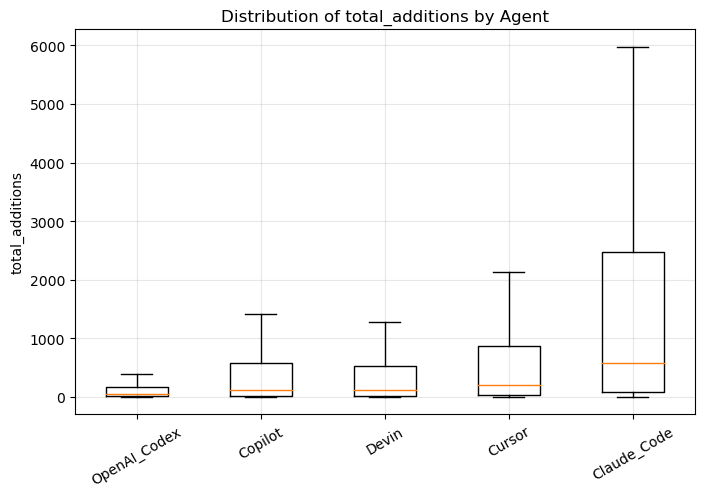

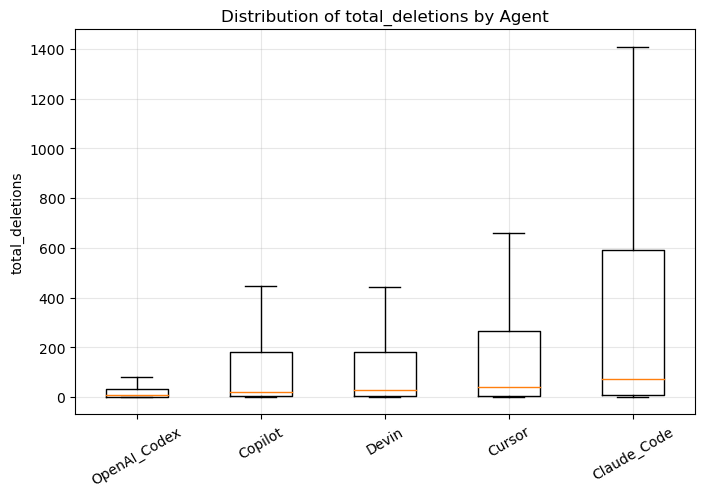

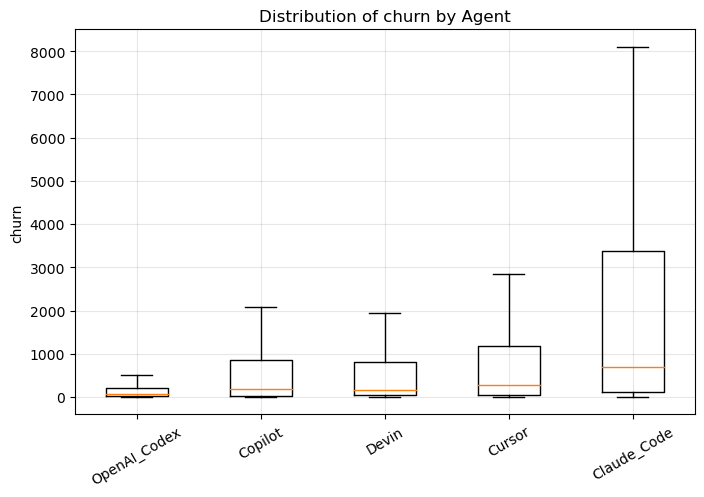

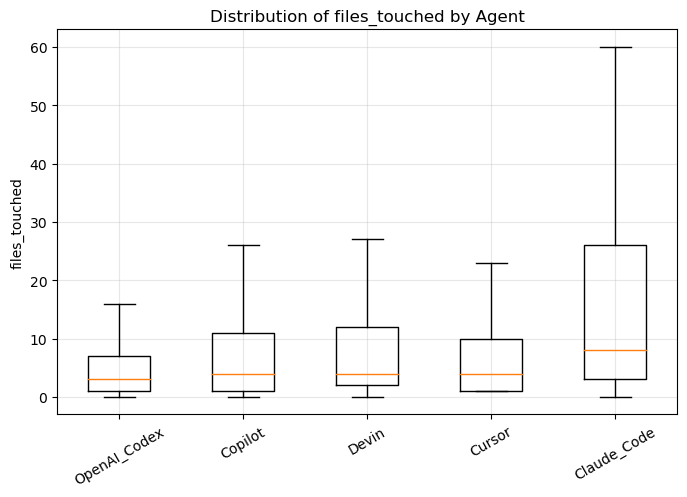

In [12]:
def plot_box(metric):
    plt.figure(figsize=(8,5))
    data = [
        metrics_df.loc[metrics_df["agent"] == ag, metric].dropna()
        for ag in agents
    ]
    plt.boxplot(data, labels=agents, showfliers=False)
    plt.title(f"Distribution of {metric} by Agent")
    plt.ylabel(metric)
    plt.xticks(rotation=30)
    plt.grid(alpha=0.3)
    plt.show()

for col in ["total_additions", "total_deletions", "churn", "files_touched"]:
    plot_box(col)


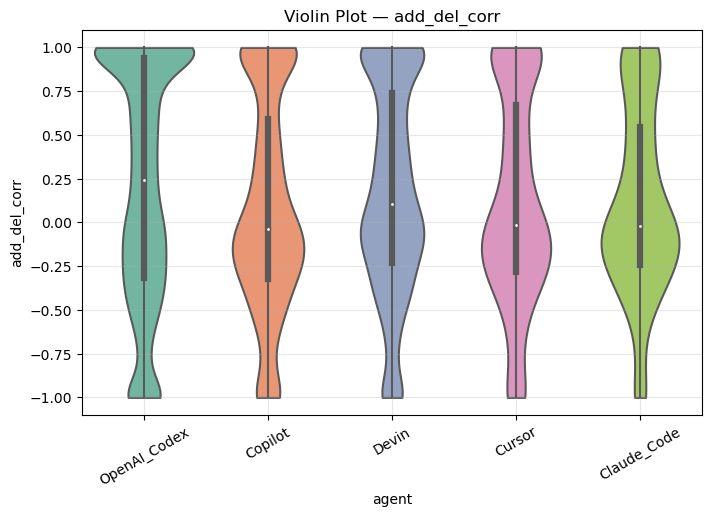

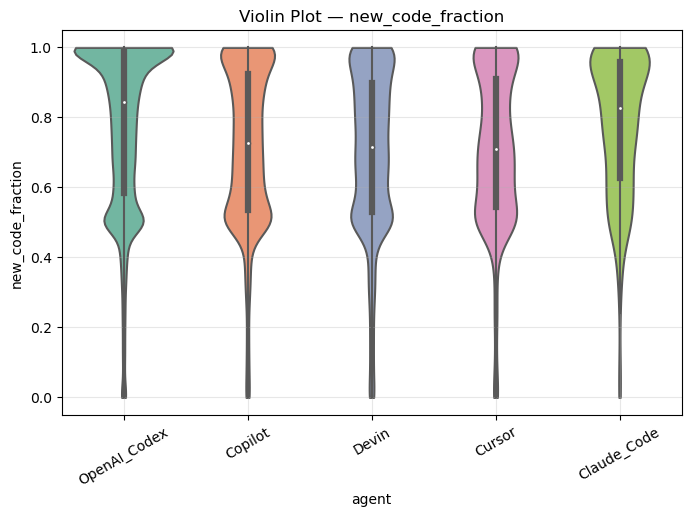

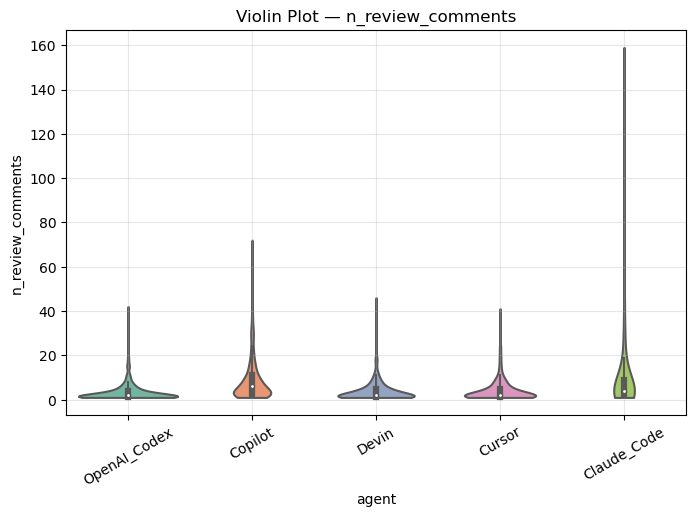

In [13]:
import seaborn as sns

def plot_violin(metric):
    plt.figure(figsize=(8,5))
    sns.violinplot(
        data=metrics_df,
        x="agent", y=metric,
        order=agents,
        palette=agent_to_color,
        cut=0
    )
    plt.title(f"Violin Plot — {metric}")
    plt.xticks(rotation=30)
    plt.grid(alpha=0.3)
    plt.show()

for col in ["add_del_corr", "new_code_fraction", "n_review_comments"]:
    plot_violin(col)


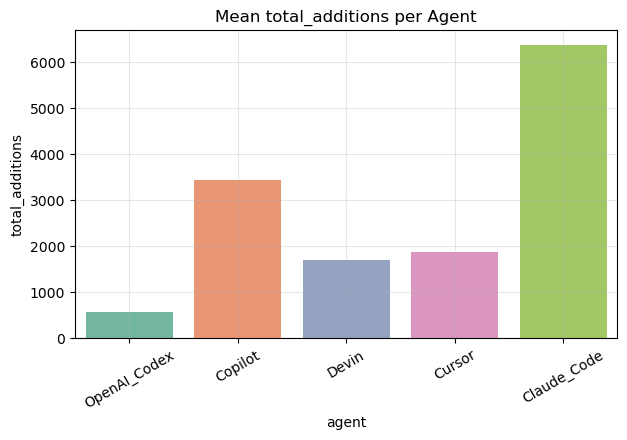

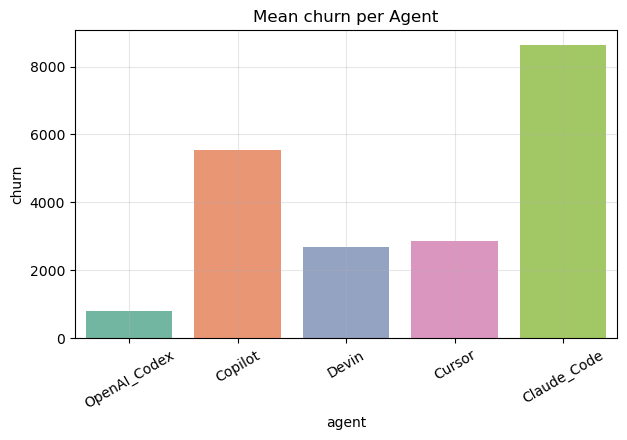

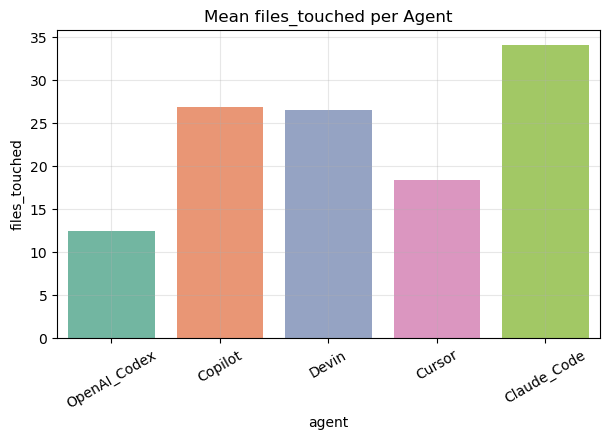

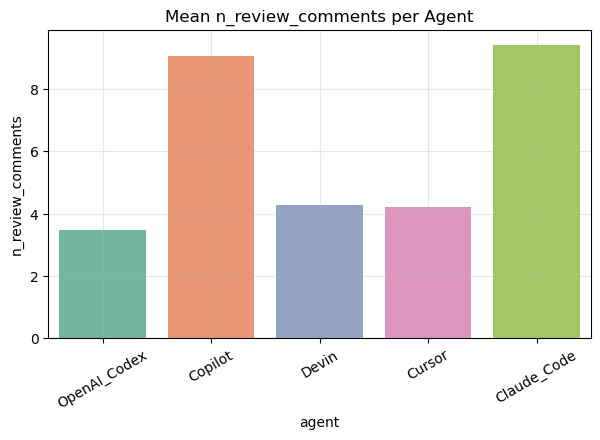

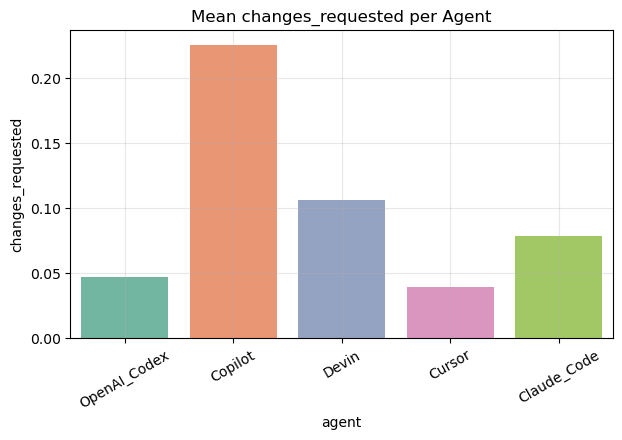

In [14]:
def plot_bar(metric):
    plt.figure(figsize=(7,4))
    means = metrics_df.groupby("agent")[metric].mean().loc[agents]
    sns.barplot(x=means.index, y=means.values, palette=agent_to_color)
    plt.title(f"Mean {metric} per Agent")
    plt.ylabel(metric)
    plt.xticks(rotation=30)
    plt.grid(alpha=0.3)
    plt.show()

bar_metrics = [
    "total_additions", "churn", "files_touched",
    "n_review_comments", "changes_requested"
]

for col in bar_metrics:
    plot_bar(col)


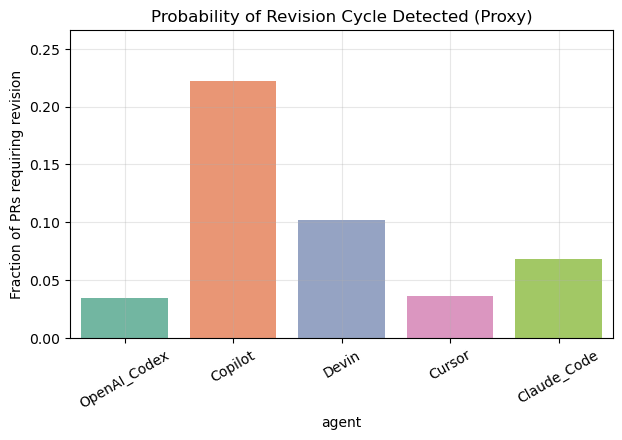

In [15]:
rev_df = (
    metrics_df
    .groupby("agent")["revision_cycle_detected"]
    .mean()
    .loc[agents]
)

plt.figure(figsize=(7,4))
sns.barplot(x=rev_df.index, y=rev_df.values, palette=agent_to_color)
plt.title("Probability of Revision Cycle Detected (Proxy)")
plt.ylabel("Fraction of PRs requiring revision")
plt.xticks(rotation=30)
plt.ylim(0, rev_df.max()*1.2)
plt.grid(alpha=0.3)
plt.show()


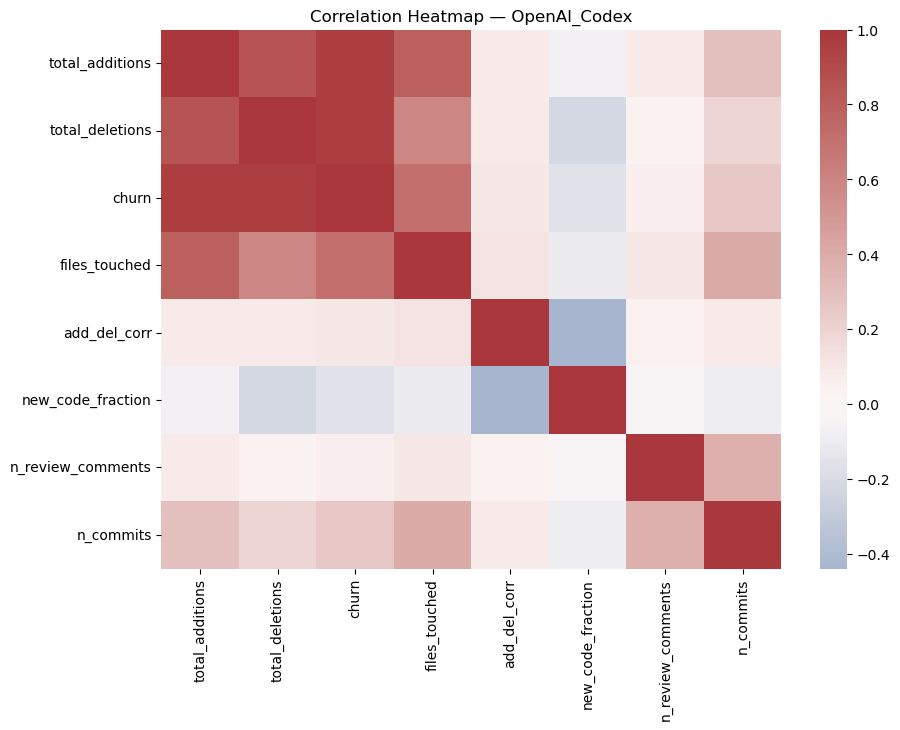

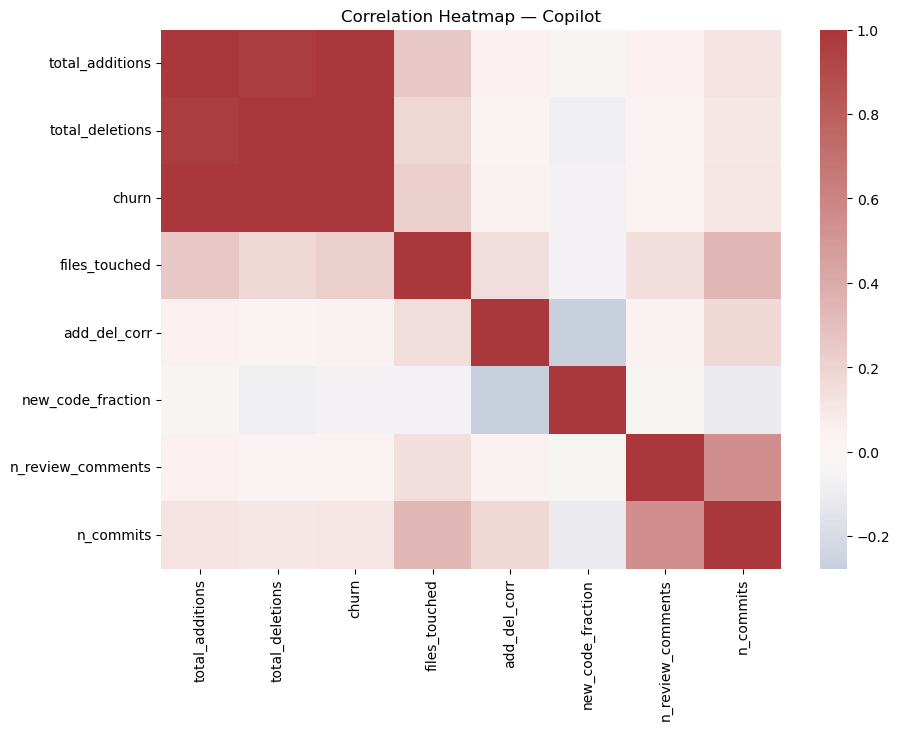

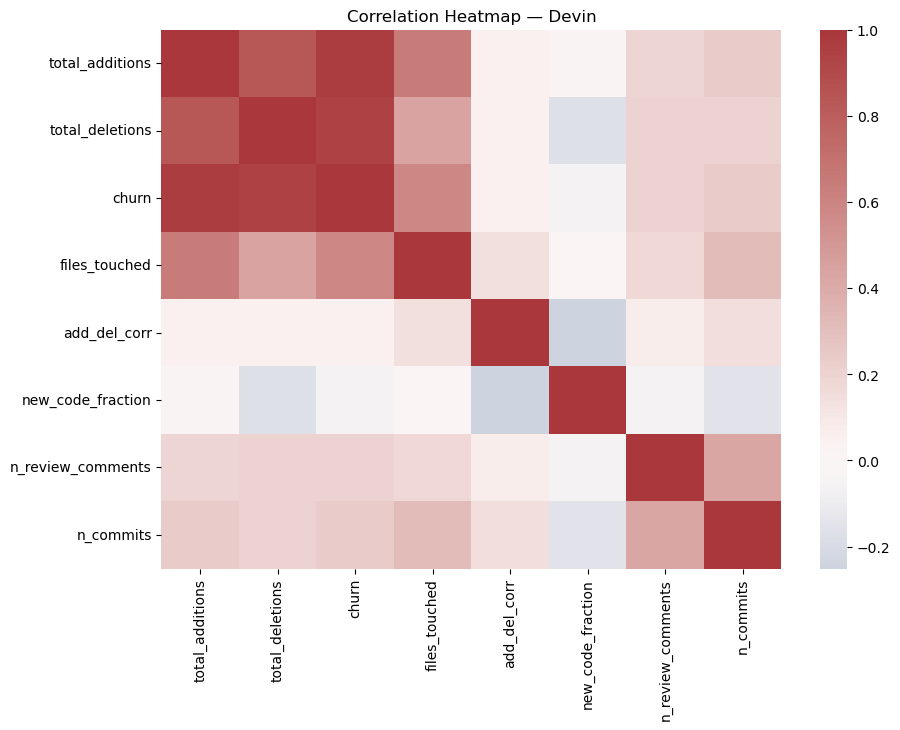

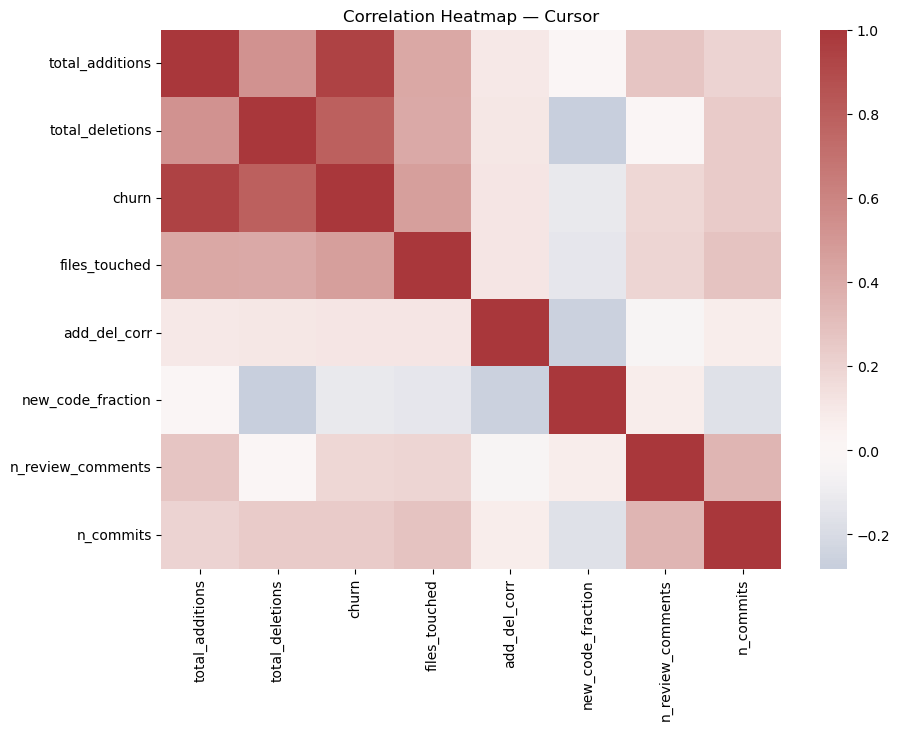

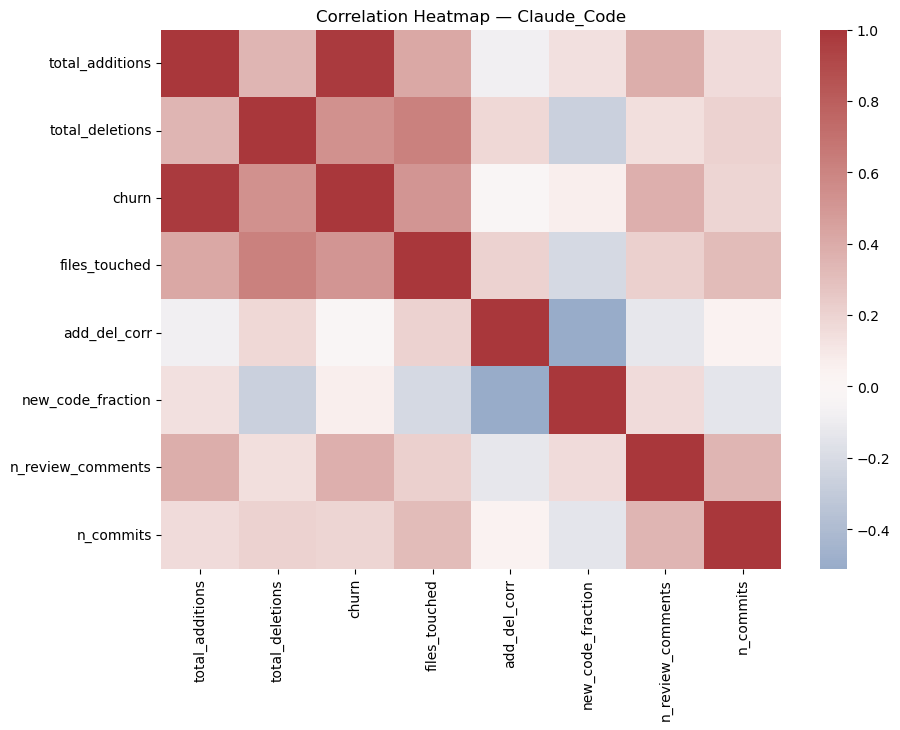

In [16]:
import numpy as np

metrics_for_corr = [
    "total_additions", "total_deletions", "churn",
    "files_touched", "add_del_corr", "new_code_fraction",
    "n_review_comments", "n_commits"
]

for ag in agents:
    sub = metrics_df[metrics_df["agent"] == ag][metrics_for_corr].dropna()
    if len(sub) < 50:
        continue

    plt.figure(figsize=(10,7))
    sns.heatmap(sub.corr(), annot=False, cmap="vlag", center=0)
    plt.title(f"Correlation Heatmap — {ag}")
    plt.show()


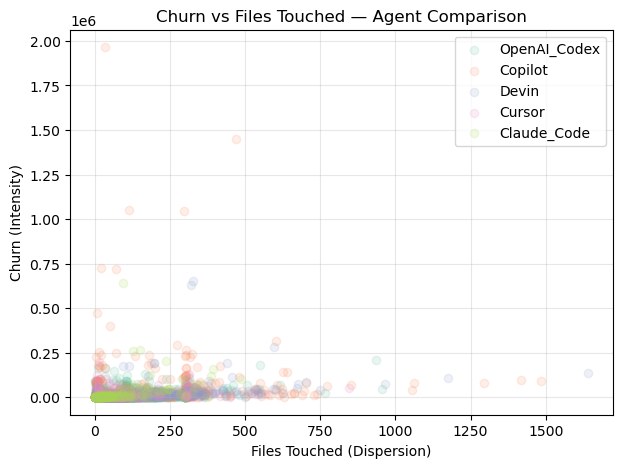

In [17]:
plt.figure(figsize=(7,5))
for ag in agents:
    subset = metrics_df[metrics_df["agent"] == ag]
    plt.scatter(
        subset["files_touched"],
        subset["churn"],
        alpha=0.15,
        label=ag,
        color=agent_to_color[ag]
    )

plt.xlabel("Files Touched (Dispersion)")
plt.ylabel("Churn (Intensity)")
plt.title("Churn vs Files Touched — Agent Comparison")
plt.legend()
plt.grid(alpha=0.3)
plt.show()
